In [61]:
import os
import time
import requests
from bs4 import BeautifulSoup as bs
from selenium import webdriver 
from selenium.webdriver.common.by import By # This needs to be used 

In [62]:
from selenium import webdriver


product="white shoes"
# Define the path to the Chrome WebDriver executable

# Initialize the Chrome WebDriver
driver = webdriver.Chrome()

# Navigate to the URL
driver.get("https://www.myntra.com/shoes?rawQuery="+product)

# Wait for the page to load (you may need to adjust the waiting time)
# You can use WebDriverWait for this purpose.
# Example: WebDriverWait(driver, 10).until(lambda x: x.find_element_by_id("element_id").is_displayed())

# Once the page is loaded, you can extract the page's text
myntra_text = driver.page_source


myntra_html = bs(myntra_text, "html.parser")#from the markup format we are converting it to the html format 

<html lang="en"><head><title>Shop the Latest Shoes for Men, Women &amp; Kids Online | Best Prices &amp; Up to 50% Off | Myntra</title><meta content="#fffff" name="theme-color"/><link href="https://constant.myntassets.com" rel="dns-prefetch preconnect"/><link href="https://assets.myntassets.com" rel="dns-prefetch preconnect"/><link href="https//www.googletagmanager.com" rel="dns-prefetch preconnect"/><link href="https//www.google-analytics.com" rel="dns-prefetch preconnect"/><link href="https//connect.facebook.net" rel="dns-prefetch preconnect"/><link href="https://www.facebook.com" rel="dns-prefetch preconnect"/><link href="https://touch.myntra.com" rel="dns-prefetch preconnect"/><link href="/manifest.json" rel="manifest"/><link href="https://www.myntra.com/opensearch.xml" rel="search" title="Myntra Fashion Search" type="application/opensearchdescription+xml"/><link href="https://constant.myntassets.com/pwa/assets/img/Icon-App-60x60@3x_2021.png" rel="apple-touch-icon"/>
<link as="scrip
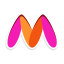

In [63]:
myntra_html

In [64]:
pclass=myntra_html.findAll("ul", {"class": "results-base"}) #find alll is similar to find element but it will give us all the elements which are similar to the one we are looking for and it will give us a list of those elements
pclass[0]      


C:\Users\Bhavishya\AppData\Local\Temp\ipykernel_12472\1727294712.py:1: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  pclass=myntra_html.findAll("ul", {"class": "results-base"}) #find alll is similar to find element but it will give us all the elements which are similar to the one we are looking for and it will give us a list of those elements


<ul class="results-base"><li class="product-base" id="34642208"><div class="product-thumbShim"></div><div class="product-ratingsContainer"><span>4.1</span><span class="myntraweb-sprite product-starIcon index-productRatingsExcellentIcon sprites-productRatingsExcellentIcon"></span><div class="product-ratingsCount"><div class="product-separator">|</div><!-- react-text: 384 -->790<!-- /react-text --></div></div><div class="product-waterMark"> AD </div><a data-refreshpage="true" href="sports-shoes/asics/asics-men-woven-design-round-toe-jolt-4-running-shoes-/34642208/buy" style="display: block;" target="_blank"><div class="product-imageSliderContainer"><div class="product-sliderContainer" style="display: block;"><div style="background: rgb(255, 242, 223);"><div style="height: 280px; width: 100%;"><picture class="img-responsive" draggable="false" style="width: 100%; height: 100%; display: block;"><source srcset="
    https://assets.myntassets.com/f_webp,dpr_1.0,q_60,w_210,c_limit,fl_progressi

In [65]:
for i in pclass:
    href = i.find_all('a', href=True)
    t=(href[0]['href'])
    
   
productLink = "https://www.myntra.com/"+ t
productLink

'https://www.myntra.com/sports-shoes/asics/asics-men-woven-design-round-toe-jolt-4-running-shoes-/34642208/buy'

In [66]:
driver.get(productLink)
prodRes= driver.page_source



<html lang="en"><head><style data-vjs-version="7.21.4" id="bc-style-vjs" type="text/css">@charset "UTF-8";.video-js .vjs-big-play-button .vjs-icon-placeholder:before,.video-js .vjs-modal-dialog,.vjs-button>.vjs-icon-placeholder:before,.vjs-modal-dialog .vjs-modal-dialog-content{position:absolute;top:0;left:0;width:100%;height:100%}.video-js .vjs-big-play-button .vjs-icon-placeholder:before,.vjs-button>.vjs-icon-placeholder:before{text-align:center}@font-face{font-family:VideoJS;src:url(data:application/font-woff;charset=utf-8;base64,d09GRgABAAAAABDkAAsAAAAAG6gAAQAAAAAAAAAAAAAAAAAAAAAAAAAAAABHU1VCAAABCAAAADsAAABUIIslek9TLzIAAAFEAAAAPgAAAFZRiV3hY21hcAAAAYQAAADaAAADPv749/pnbHlmAAACYAAAC3AAABHQZg6OcWhlYWQAAA3QAAAAKwAAADYZw251aGhlYQAADfwAAAAdAAAAJA+RCLFobXR4AAAOHAAAABMAAACM744AAGxvY2EAAA4wAAAASAAAAEhF6kqubWF4cAAADngAAAAfAAAAIAE0AIFuYW1lAAAOmAAAASUAAAIK1cf1oHBvc3QAAA/AAAABJAAAAdPExYuNeJxjYGRgYOBiMGCwY2BycfMJYeDLSSzJY5BiYGGAAJA8MpsxJzM9kYEDxgPKsYBpDiBmg4gCACY7BUgAeJxjYGS7wTiBgZWBgaWQ5RkDA8MvC
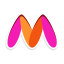

In [67]:
prodRes_html = bs(prodRes, "html.parser")
prodRes_html

In [68]:
title_h=prodRes_html.findAll("title")#used for filtering the title of the product
title=title_h[0].text
title

C:\Users\Bhavishya\AppData\Local\Temp\ipykernel_12472\158240275.py:1: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  title_h=prodRes_html.findAll("title")#used for filtering the title of the product


'Buy ASICS Men Woven Design Round Toe JOLT 4 Running Shoes  - Sports Shoes for Men 34642208 | Myntra'

In [69]:
overallRating=prodRes_html.findAll("div",{"class":"index-overallRating"})
overallRating
for i in overallRating:
    rating_value = i.find('div').text
print(rating_value)


4.1


C:\Users\Bhavishya\AppData\Local\Temp\ipykernel_12472\1208185265.py:1: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  overallRating=prodRes_html.findAll("div",{"class":"index-overallRating"})


In [70]:
price=prodRes_html.findAll("span",{"class":"pdp-price"})
for i in price:
    p=i.text
print(p)

₹2114


C:\Users\Bhavishya\AppData\Local\Temp\ipykernel_12472\61606019.py:1: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  price=prodRes_html.findAll("span",{"class":"pdp-price"})


In [71]:
Reviews=prodRes_html.find("a",{"class":"detailed-reviews-allReviews"})
t2=Reviews['href']
Review_link="https://www.myntra.com"+t2
Review_link

'https://www.myntra.com/reviews/34642208'

In [72]:
driver.get(Review_link)
review_page= driver.page_source #extracting the source of the web page 
driver.quit()

<html lang="en"><head><title>Review - ASICS Men Woven Design Round-Toe JOLT 4 Running Shoes</title><meta content="#fffff" name="theme-color"/><link href="https://constant.myntassets.com" rel="dns-prefetch preconnect"/><link href="https://assets.myntassets.com" rel="dns-prefetch preconnect"/><link href="https//www.googletagmanager.com" rel="dns-prefetch preconnect"/><link href="https//www.google-analytics.com" rel="dns-prefetch preconnect"/><link href="https//connect.facebook.net" rel="dns-prefetch preconnect"/><link href="https://www.facebook.com" rel="dns-prefetch preconnect"/><link href="https://touch.myntra.com" rel="dns-prefetch preconnect"/><link href="/manifest.json" rel="manifest"/><link href="https://www.myntra.com/opensearch.xml" rel="search" title="Myntra Fashion Search" type="application/opensearchdescription+xml"/><link href="https://constant.myntassets.com/pwa/assets/img/Icon-App-60x60@3x_2021.png" rel="apple-touch-icon"/>
<link as="script" href="https://constant.myntasset
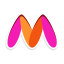

In [73]:
review_html = bs(review_page, "html.parser")
review_html


In [74]:
review=review_html.findAll("div",{"class":"detailed-reviews-userReviewsContainer"})

C:\Users\Bhavishya\AppData\Local\Temp\ipykernel_12472\4034511439.py:1: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  review=review_html.findAll("div",{"class":"detailed-reviews-userReviewsContainer"})


In [75]:
for i in review:
    user_rating=i.findAll("div",{"class":"user-review-main user-review-showRating"})
    user_comment=i.findAll("div",{"class":"user-review-reviewTextWrapper"})
    user_name=i.findAll("div",{"class":"user-review-left"})

C:\Users\Bhavishya\AppData\Local\Temp\ipykernel_12472\345188362.py:2: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  user_rating=i.findAll("div",{"class":"user-review-main user-review-showRating"})
C:\Users\Bhavishya\AppData\Local\Temp\ipykernel_12472\345188362.py:3: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  user_comment=i.findAll("div",{"class":"user-review-reviewTextWrapper"})
C:\Users\Bhavishya\AppData\Local\Temp\ipykernel_12472\345188362.py:4: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  user_name=i.findAll("div",{"class":"user-review-left"})


In [76]:
len(user_rating),len(user_comment),len(user_name)

(12, 12, 12)

In [77]:
for i in range(len(user_rating)):
    rating = user_rating[i].find('span', class_='user-review-starRating').get_text().strip()
    comment=user_comment[i].text
    name = user_name[i].find('span').text
    date = user_name[i].find_all('span')[1].text    
    print(f"Date: {date},Rating: {rating},Name:{name},Comment:{comment}")

Date: 3 July 2025,Rating: 4,Name:Neeta,Comment:The Asics shorts offer excellent quality with breathable fabric and durable stitching, perfect for workouts or casual wear. Their fit is comfortable, allowing easy movement. At such an affordable price, they truly deliver great value. These shorts are a smart buy for anyone looking for performance and comfort without breaking the bank. Definitely worth every penny!


Date: 24 June 2025,Rating: 4,Name:Myntra Customer,Comment:I bought these shoes one size up, hoping for a better fit, but I still found them very difficult to wear — especially around the heel and back area. The opening is quite tight and putting them on requires some effort. Once they’re on, the build quality and design are great, with a comfortable sole and good overall support. However, the snug heel could be an issue for anyone with a wider foot or if you prefer a looser fit. Quality-wise they feel durable and well-made, but I’d recommend trying them on in-store if possible

In [78]:
for i in user_comment:
    com=i.text
    print(com)

The Asics shorts offer excellent quality with breathable fabric and durable stitching, perfect for workouts or casual wear. Their fit is comfortable, allowing easy movement. At such an affordable price, they truly deliver great value. These shorts are a smart buy for anyone looking for performance and comfort without breaking the bank. Definitely worth every penny!


I bought these shoes one size up, hoping for a better fit, but I still found them very difficult to wear — especially around the heel and back area. The opening is quite tight and putting them on requires some effort. Once they’re on, the build quality and design are great, with a comfortable sole and good overall support. However, the snug heel could be an issue for anyone with a wider foot or if you prefer a looser fit. Quality-wise they feel durable and well-made, but I’d recommend trying them on in-store if possible before buying.
The product is great,it's Asics so it has to be great. But the height is small,like after

In [79]:
for item in user_name:
    name = item.find('span').text
    date = item.find_all('span')[1].text
    print(f"Name: {name}, Date: {date}")

Name: Neeta, Date: 3 July 2025
Name: Myntra Customer, Date: 24 June 2025
Name: Prashant, Date: 10 June 2025
Name: Adv Saiprasad Rathod, Date: 20 Dec 2025
Name: Saurav Kumar, Date: 14 May 2025
Name: Sonu Hooda, Date: 1 Jan 2026
Name: Gautam Saikia, Date: 8 Sept 2025
Name: Vbn Cycling, Date: 5 July 2025
Name: Ritesh Kumathe, Date: 7 Oct 2025
Name: Vatsal Shukla, Date: 10 Apr 2025
Name: Supriya Gupta, Date: 4 Aug 2025
Name: Meenakshi Na, Date: 25 Oct 2025


In [82]:
from urllib.parse import quote


search_query = "denim jeans"
encoded_query = quote(search_query)
encoded_query

'denim%20jeans'

In [83]:
import requests
from bs4 import BeautifulSoup

url = 'https://en.wikipedia.org/wiki/Elon_Musk'

# Sending a GET request to the URL
response = requests.get(url)

# Parsing the HTML content using BeautifulSoup
soup = BeautifulSoup(response.text, 'html.parser')

# Finding all anchor tags (a) that contain href attribute
href_tags = soup.find_all('a', href=True)

# Extracting href attribute from anchor tags
href_links = [tag['href'] for tag in href_tags]

print(href_links)


[]
